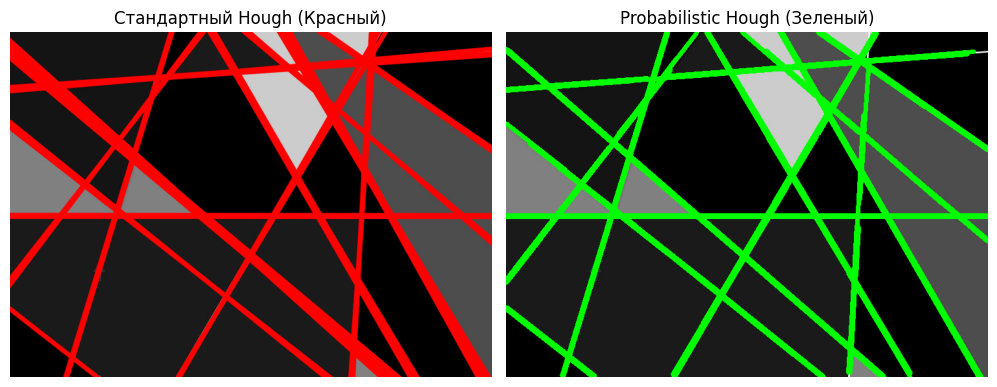

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

img = cv2.imread('data_img/lines.jpg')
img_original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Детектируем границы с помощью алгоритма Canny
# Пороги: 50 (нижний) и 200 (верхний)
# Пиксели с градиентом выше 200 считаются границами, ниже 50 - игнорируются
# Пиксели между 50 и 200 считаются границами, если связаны с сильными границами
edges = cv2.Canny(gray, 50, 200, None, 3)

img_standard = img.copy()
img_probabilistic = img.copy()

# Функция HoughLines находит линии в полярных координатах (ρ, θ)
# Параметры:
# - edges: бинарное изображение с границами
# - 2: шаг по расстоянию ρ (в пикселях)
# - np.pi/180: шаг по углу θ (в радианах, здесь 1 градус)
# - 150: порог аккумулятора (минимальное количество голосов для линии)
lines = cv2.HoughLines(edges, 1, np.pi/180, 150, None, 0, 0)

if lines is not None:
    for i in range(0, len(lines)):
        rho = lines[i][0][0]
        theta = lines[i][0][1]
        a = math.cos(theta)
        b = math.sin(theta)
        x0 = a * rho
        y0 = b * rho
        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
        cv2.line(img_standard, pt1, pt2, (0,0,255), 5, cv2.LINE_AA)

# Функция HoughLinesP находит отрезки линий (с началом и концом)
# Параметры:
# edges: бинарное изображение с границами
# 1: шаг по расстоянию ρ
# np.pi/180: шаг по углу θ
# 50: порог аккумулятора (минимальное количество голосов)
# 50: минимальная длина отрезка (пиксели)
# 10: максимальный разрыв между точками одной линии
lines_p = cv2.HoughLinesP(edges, 1, np.pi / 180, 50, None, 50, 10)

# Перебираем все найденные отрезки
for x1, y1, x2, y2 in lines_p[:, 0]:
    # Рисуем отрезок на изображении вероятностным преобразованием Хафа
    cv2.line(img_probabilistic, (x1, y1), (x2, y2), (0, 255, 0), 5)

plt.figure(figsize=(20, 10))

plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(img_standard, cv2.COLOR_BGR2RGB))
plt.title('Стандартный Hough (Красный)')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(cv2.cvtColor(img_probabilistic, cv2.COLOR_BGR2RGB))
plt.title('Probabilistic Hough (Зеленый)')
plt.axis('off')

plt.tight_layout()
plt.show()

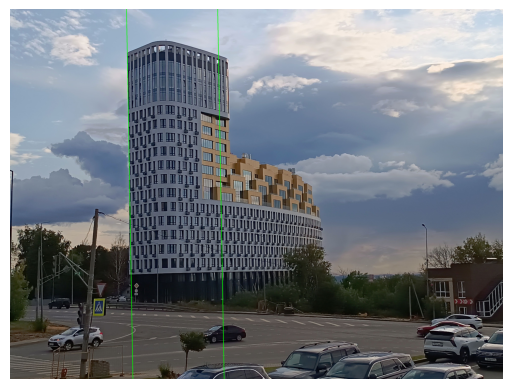

In [27]:

path_to_file = 'data_img/skyskeb_one.jpg'
img = cv2.imread(path_to_file, 0) # Полутоновое изображение
color_img = cv2.imread(path_to_file) # Цветное изображение

img = cv2.GaussianBlur(img, (3,3), 0)
edges = cv2.Canny(img, 50, 200)
lines = cv2.HoughLines(edges, 2, np.pi/180, 700)

# Допустимое отклонение от вертикали (в радианах)
vertical_angle = np.pi  # 90 градусов
angle_tolerance = np.pi / 12  # 15 градусов допуска (можно изменить)

multiplier = 4000

displayed_lines = []

for line in lines:
    rho, theta = line[0]
    if abs(theta - vertical_angle) < angle_tolerance or abs(theta + vertical_angle) < angle_tolerance:
        k1, k2 = np.cos(theta), np.sin(theta)
        x0, y0 = k1*rho, k2*rho
        x1, y1 = int(x0 + multiplier*(-k2)), int(y0 + multiplier*k1)
        x2, y2 = int(x0 - multiplier*(-k2)), int(y0 - multiplier*k1)
        displayed_lines.append((x1, y1, x2, y2))

displayed_lines.sort(key=lambda x: x[0])
cv2.line(color_img, (displayed_lines[0][0], displayed_lines[0][1]), (displayed_lines[0][2], displayed_lines[0][3]), (0, 255, 0), 3)
cv2.line(color_img, (displayed_lines[-1][0], displayed_lines[-1][1]), (displayed_lines[-1][2], displayed_lines[-1][3]), (0, 255, 0), 3)

plt.figure()
plt.imshow(cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


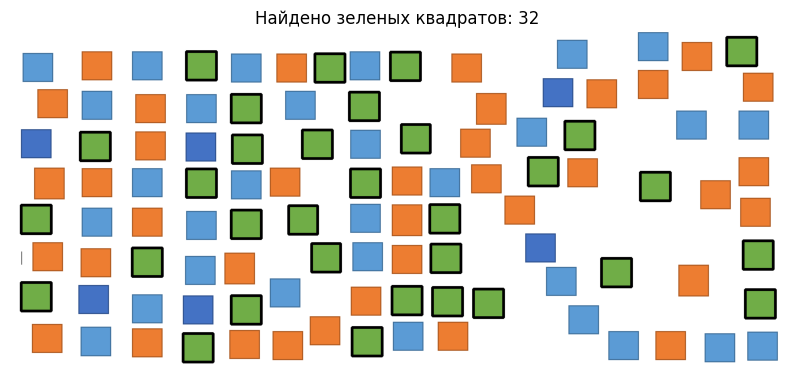

Количество зеленых квадратов: 32


In [ ]:
img = cv2.imread('data_img/square_many.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # для отображения в matplotlib

# выделяем зеленые области: переводим в HSV для лучшего определения цвета
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
# зеленый цвет в HSV: Hue ~ 40-80, насыщенность >50, яркость >50
lower_green = np.array([40, 50, 50])
upper_green = np.array([80, 255, 255])
mask = cv2.inRange(hsv, lower_green, upper_green)  # бинарная маска зеленых областей

# морфология для удаления шума и заполнения дыр
kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)  # закрытие
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)   # открытие

# находим контуры зеленых областей
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

count = 0
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 500: continue  # отсеиваем слишком маленькие
    
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.04 * peri, True)  # аппроксимируем контур
    
    if len(approx) == 4:  # проверяем, что это четырехугольник (квадрат/прямоугольник)
        # дополнительная проверка: отношение сторон должно быть близко к 1 (квадрат)
        x, y, w, h = cv2.boundingRect(approx)
        if 0.8 < w/h < 1.2:  # допуск 20% на искажение
            cv2.drawContours(img, [cnt], -1, (0, 0, 0), 3)  # черная рамка
            count += 1

# отображение результата
plt.figure(figsize=(10,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f'Найдено зеленых квадратов: {count}')
plt.axis('off')
plt.show()

print(f"Количество зеленых квадратов: {count}")